# Bank of Canada Speech Hawkishness — Verification Notebook

Run this after completing the tournament and scoring pipeline.

**Pipeline:**
1. `scrape_speeches.py` → `data/speeches_raw.json`
2. `build_tournament.py` → `data/tournament_results.json`
3. `score_speeches.py` → `data/speeches_scored.csv`


In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

df = pd.read_csv("data/speeches_scored.csv", parse_dates=["date"])
print(f"Loaded {len(df)} speeches")
print(f"Date range: {df.date.min().date()} to {df.date.max().date()}")
print(f"Speakers: {df.speaker.nunique()}")
df.head()

Loaded 786 speeches
Date range: 1995-03-30 to 2026-03-04
Speakers: 33


,date,speaker,title,url,trueskill_mu,trueskill_sigma,comparisons,raw_score,era_adjusted_score
0,1995-03-30,Gordon Thiessen,Uncertainty and the Transmission of Monetary P...,https://www.bankofcanada.ca/1995/03/uncertaint...,19.8358,1.9963,39,30.93,50.00
1,1996-06-27,Gordon Thiessen,Some current economic issues in Canada,https://www.bankofcanada.ca/1996/06/some-curre...,30.3653,1.9769,36,55.47,50.00
2,1997-03-21,Gordon Thiessen,Monetary Policy and the Prospects for a Strong...,https://www.bankofcanada.ca/1997/03/monetary-p...,32.1058,1.9973,29,59.53,50.00
3,1997-05-30,Gordon Thiessen,Flexible Exchange Rates in a World of Low Infl...,https://www.bankofcanada.ca/1997/05/flexible-e...,16.3786,1.9989,33,22.87,35.54
4,1997-06-18,Gordon Thiessen,The Canadian economy: Challenges and prospects,https://www.bankofcanada.ca/1997/06/canadian-e...,28.7865,1.9596,29,51.79,64.46


## 1. Tournament Convergence Check

In [52]:
# All sigma should be < 2.0 (tournament convergence criterion)
unconverged = df[df.trueskill_sigma >= 2.0]
print(f"Unconverged speeches (sigma >= 2.0): {len(unconverged)}")
if len(unconverged) > 0:
    print("WARNING: Some speeches did not converge!")
    print(unconverged[["date", "speaker", "title", "trueskill_sigma"]].to_string())
else:
    print("All speeches converged. ✓")

print(f"\nComparisons per speech — min: {df.comparisons.min()}, mean: {df.comparisons.mean():.1f}, max: {df.comparisons.max()}")


Unconverged speeches (sigma >= 2.0): 3
          date             speaker                                                        title  trueskill_sigma
331 2012-04-04         Jean Boivin      Aging Gracefully: Canada’s Inevitable Demographic Shift           2.0000
508 2018-10-24  Carolyn A. Wilkins    Monetary Policy Report Press Conference Opening Statement           4.4014
564 2020-05-01    Stephen S. Poloz  Statement by Governor Poloz on Announcement of New Governor           4.2930

Comparisons per speech — min: 18, mean: 37.7, max: 2195


## 2. Score Distributions

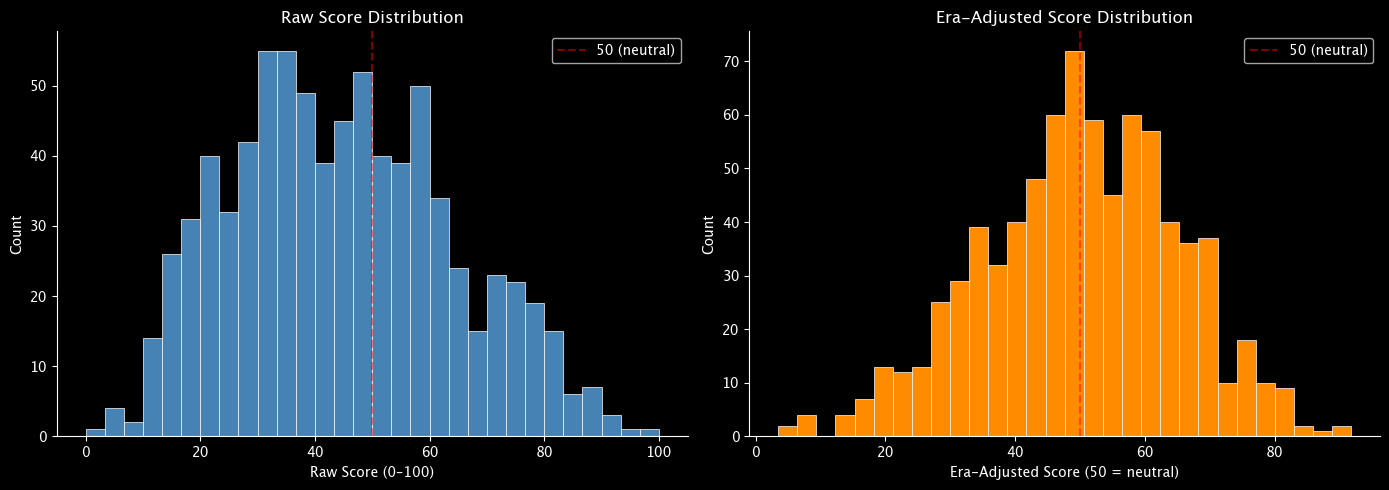

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["raw_score"], bins=30, color="steelblue", edgecolor="white", linewidth=0.5)
axes[0].set_title("Raw Score Distribution")
axes[0].set_xlabel("Raw Score (0–100)")
axes[0].set_ylabel("Count")
axes[0].axvline(50, color="red", linestyle="--", alpha=0.5, label="50 (neutral)")
axes[0].legend()

axes[1].hist(df["era_adjusted_score"], bins=30, color="darkorange", edgecolor="white", linewidth=0.5)
axes[1].set_title("Era-Adjusted Score Distribution")
axes[1].set_xlabel("Era-Adjusted Score (50 = neutral)")
axes[1].set_ylabel("Count")
axes[1].axvline(50, color="red", linestyle="--", alpha=0.5, label="50 (neutral)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Hawkishness Over Time

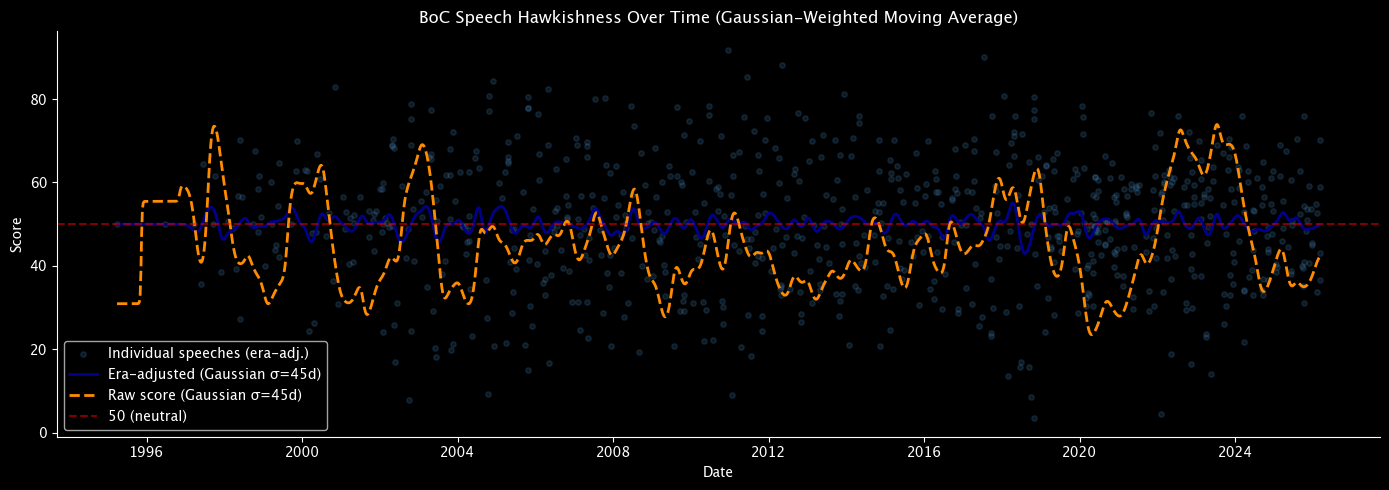

In [54]:
import numpy as np

# Gaussian-weighted moving average (σ=45 days, sampled weekly)
df_sorted = df.sort_values("date").copy()
dates = df_sorted["date"].values.astype("datetime64[D]").astype(float)
era_scores = df_sorted["era_adjusted_score"].values
raw_scores = df_sorted["raw_score"].values

sigma = 45  # days
sample_dates = np.arange(dates.min(), dates.max() + 1, 7)  # weekly steps

def gaussian_wavg(sample_days, data_days, values, sigma):
    out = np.empty(len(sample_days))
    for i, t in enumerate(sample_days):
        w = np.exp(-0.5 * ((data_days - t) / sigma) ** 2)
        out[i] = np.sum(w * values) / np.sum(w)
    return out

gwma_era = gaussian_wavg(sample_dates, dates, era_scores, sigma)
gwma_raw = gaussian_wavg(sample_dates, dates, raw_scores, sigma)
sample_dt = pd.to_datetime(sample_dates.astype(int), unit="D", origin="unix")

fig, ax = plt.subplots(figsize=(14, 5))
ax.scatter(df_sorted["date"], era_scores, alpha=0.2, s=15, color="steelblue",
           label="Individual speeches (era-adj.)")
ax.plot(sample_dt, gwma_era, color="darkblue", linewidth=2,
        label="Era-adjusted (Gaussian σ=45d)")
ax.plot(sample_dt, gwma_raw, color="darkorange", linewidth=2, linestyle="--",
        label="Raw score (Gaussian σ=45d)")
ax.axhline(50, color="red", linestyle="--", alpha=0.5, label="50 (neutral)")
ax.set_title("BoC Speech Hawkishness Over Time (Gaussian-Weighted Moving Average)")
ax.set_xlabel("Date")
ax.set_ylabel("Score")
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Single CSV for Datawrapper: weekly GWMA line + individual speech dots in separate columns
line_df = pd.DataFrame({
    "date": sample_dt,
    "gwma_era_adjusted": gwma_era,
    "gwma_raw": gwma_raw,
})

speeches_reset = df_sorted.reset_index()
dots_df = pd.DataFrame({
    "date": speeches_reset["date"],
    "speaker": speeches_reset["speaker"],
    "title": speeches_reset["title"],
    "url": speeches_reset["url"],
    "era_adjusted_score": era_scores,
    "raw_score": raw_scores,
})

combined = pd.merge(line_df, dots_df, on="date", how="outer").sort_values("date")
combined.to_csv("data/rolling_hawkishness.csv", index=False, float_format="%.2f")
print(f"Exported {len(combined)} rows to data/rolling_hawkishness.csv")
combined.head(10)


Exported 2196 rows to data/rolling_hawkishness.csv


,date,gwma_era_adjusted,gwma_raw,era_adjusted_score,raw_score
0,1995-03-30,50.0,30.93,50.0,30.93
1,1995-04-06,50.0,30.93,NaN,NaN
2,1995-04-13,50.0,30.93,NaN,NaN
3,1995-04-20,50.0,30.93,NaN,NaN
4,1995-04-27,50.0,30.93,NaN,NaN
5,1995-05-04,50.0,30.93,NaN,NaN
6,1995-05-11,50.0,30.93,NaN,NaN
7,1995-05-18,50.0,30.93,NaN,NaN
8,1995-05-25,50.0,30.93,NaN,NaN
9,1995-06-01,50.0,30.93,NaN,NaN


## 4. Speaker Rankings

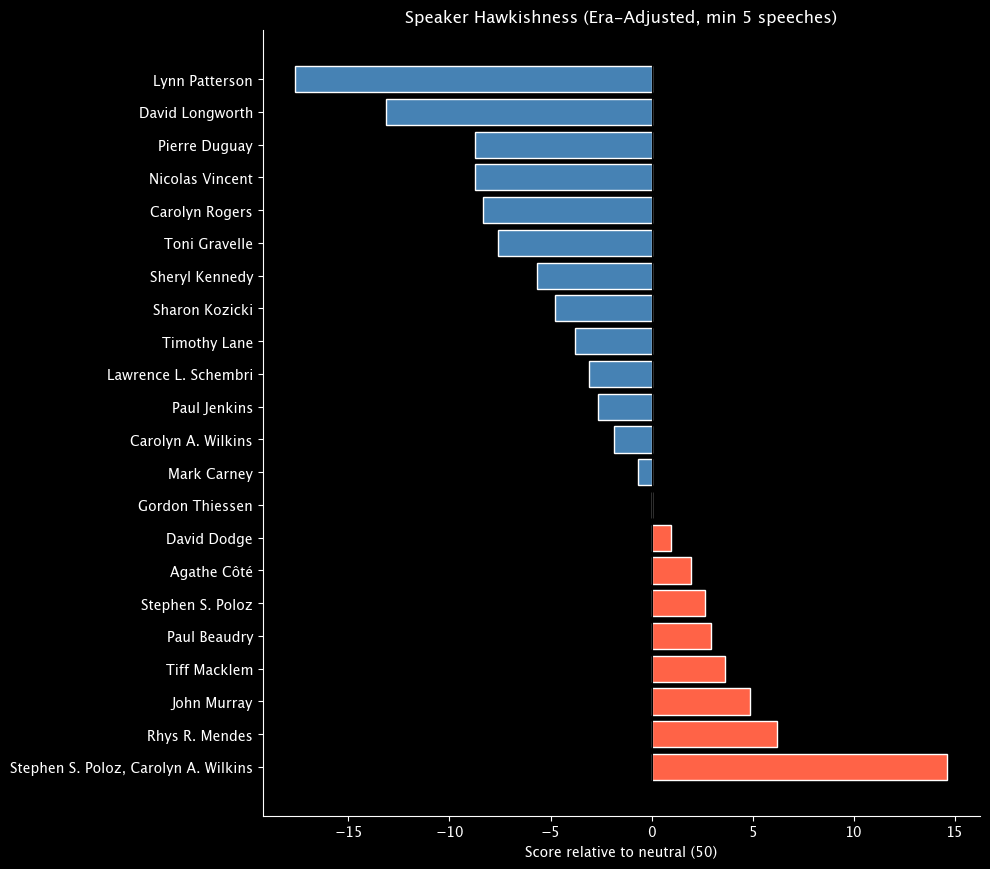

                                      avg_score  score_std  n_speeches
speaker                                                               
Stephen S. Poloz, Carolyn A. Wilkins  64.634444  15.906870           9
Rhys R. Mendes                        56.180000  14.922664           5
John Murray                           54.885833   7.672230          12
Tiff Macklem                          53.641277  11.215049         141
Paul Beaudry                          52.937857  15.124736          14
Stephen S. Poloz                      52.617864  13.968874         103
Agathe Côté                           51.955000   8.935499           8
David Dodge                           50.944636  17.281499         151
Gordon Thiessen                       49.996383  14.404647          47
Mark Carney                           49.346522  18.176965          92
Carolyn A. Wilkins                    48.123143  15.476066          35
Paul Jenkins                          47.354545  11.982210          11
Lawren

In [56]:
# Speaker averages (min 5 speeches)
speaker_stats = (
    df.groupby("speaker")["era_adjusted_score"]
    .agg(["mean", "std", "count"])
    .rename(columns={"mean": "avg_score", "std": "score_std", "count": "n_speeches"})
    .query("n_speeches >= 5")
    .sort_values("avg_score", ascending=False)
)

fig, ax = plt.subplots(figsize=(10, max(4, len(speaker_stats) * 0.4)))
colors = ["tomato" if v > 50 else "steelblue" for v in speaker_stats["avg_score"]]
ax.barh(speaker_stats.index, speaker_stats["avg_score"] - 50, color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Speaker Hawkishness (Era-Adjusted, min 5 speeches)")
ax.set_xlabel("Score relative to neutral (50)")
plt.tight_layout()
plt.show()

print(speaker_stats.to_string())

## 5. Most Hawkish and Dovish Speeches

In [57]:
cols = ["date", "speaker", "title", "era_adjusted_score", "comparisons"]

print("TOP 10 MOST HAWKISH (era-adjusted):")
print(df.nlargest(10, "era_adjusted_score")[cols].to_string(index=False))

print()
print("TOP 10 MOST DOVISH (era-adjusted):")
print(df.nsmallest(10, "era_adjusted_score")[cols].to_string(index=False))

TOP 10 MOST HAWKISH (era-adjusted):
      date                              speaker                                                                        title  era_adjusted_score  comparisons
2010-12-13                          Mark Carney                                                     Living with Low for Long               91.83           41
2017-07-12 Stephen S. Poloz, Carolyn A. Wilkins                    Monetary Policy Report Press Conference Opening Statement               89.99           55
2012-04-30                         Timothy Lane            Transport and Logistics - Connecting Canada to the Global Economy               88.11           34
2011-06-15                          Mark Carney                                                            Housing in Canada               85.25           60
2004-11-24                          David Dodge Opening Statement before the Senate Committee on Banking, Trade and Commerce               84.23           49
2000-11-09      